# Final Comparison Report: AI-Text Detection Baselines

**Objective:** This report summarizes the findings from four different detection strategies. We compare lexical methods (focused on vocabulary) against stylometric methods (focused on punctuation and syntax) to determine the most robust approach for the proposed research.

**Methods Overview:**
1. **TF-IDF + Random Forest:** Non-linear lexical baseline.
2. **TF-IDF + Logistic Regression:** Linear lexical baseline.
3. **Stylometric + Random Forest:** Non-linear structural baseline.
4. **Stylometric + Logistic Regression:** Linear structural baseline.

In [12]:
import pandas as pd
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# List of metric files from previous experiments
OUTPUT_DIR = 'output'
experiments = {
    'tfidf_rf': 'TF-IDF + Random Forest',
    'tfidf_logreg': 'TF-IDF + Logistic Regression',
    'stylo_rf': 'Stylometry + Random Forest',
    'stylo_logreg': 'Stylometry + Logistic Regression'
}
all_metrics = []

for exp_id, label in experiments.items():
    json_path = os.path.join(OUTPUT_DIR, f'metrics_{exp_id}.json')
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            data = json.load(f)
            data['name'] = label
            all_metrics.append(data)
    else:
        print(f"Warning: File {json_path} not found.")

# Creating a summary DataFrame
df_results = pd.DataFrame(all_metrics).set_index('name')
print("Summary Table of All Experiments:")
display(df_results.sort_values(by='Accuracy', ascending=False))


Summary Table of All Experiments:


,Accuracy,Precision,Recall,F1,AUC-ROC
name,,,,,
TF-IDF + Logistic Regression,0.9750,0.974052,0.976,0.975025,0.997469
TF-IDF + Random Forest,0.9660,0.969758,0.962,0.965863,0.994849
Stylometry + Random Forest,0.8640,0.886412,0.835,0.859938,0.931976
Stylometry + Logistic Regression,0.8105,0.794872,0.837,0.815392,0.896640


### 2. Performance Visualization
We visualize the trade-off between **Accuracy** and **AUC-ROC** across all methods. While lexical methods usually show higher metrics on fixed datasets, stylometric methods are expected to be more stable across different domains.

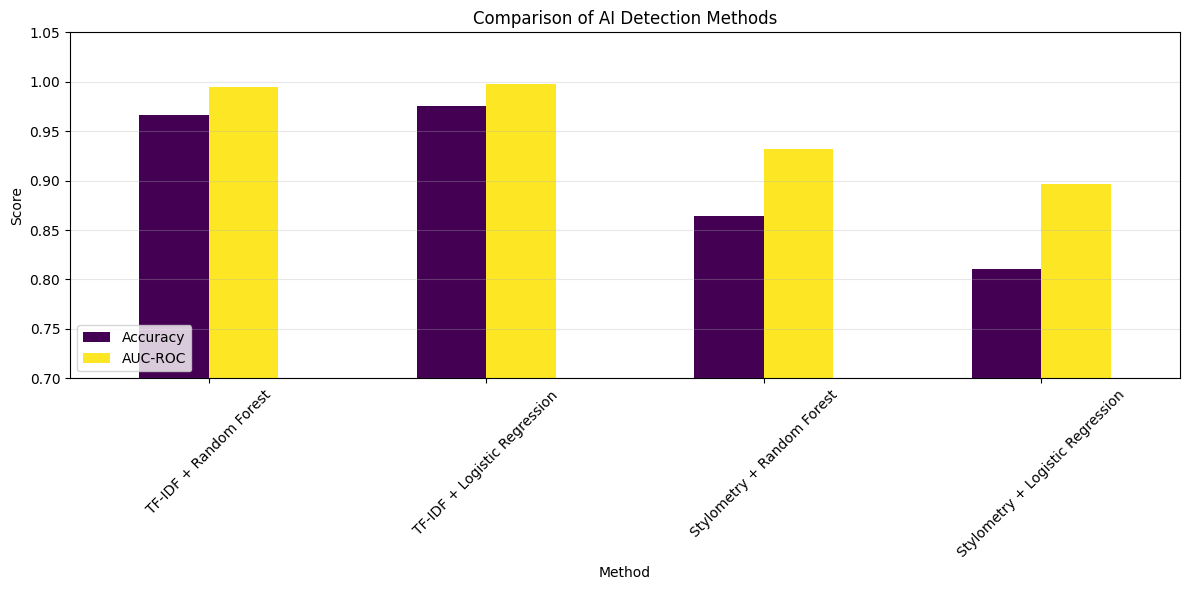

In [13]:
plt.figure(figsize=(12, 6))
df_plot = df_results[['Accuracy', 'AUC-ROC']].copy()
df_plot.plot(kind='bar', ax=plt.gca(), colormap='viridis')

plt.title('Comparison of AI Detection Methods')
plt.ylabel('Score')
plt.xlabel('Method')
plt.xticks(rotation=45)
plt.ylim(0.7, 1.05)
plt.legend(loc='lower left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

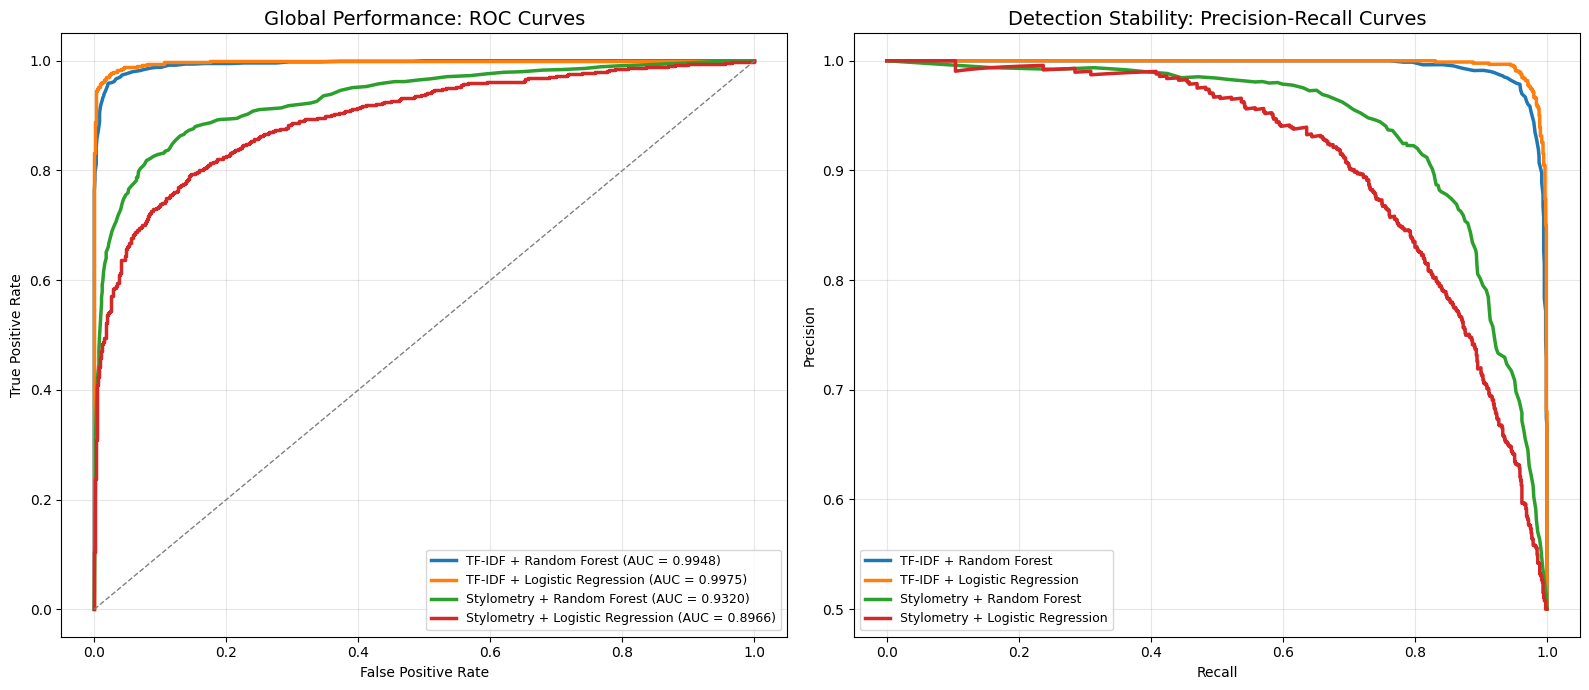

In [14]:
plt.figure(figsize=(16, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Левый график: ROC-кривые
ax1 = plt.subplot(1, 2, 1)
for i, (exp_id, label) in enumerate(experiments.items()):
    prob_path = os.path.join(OUTPUT_DIR, f'y_prob_{exp_id}.npy')
    true_path = os.path.join(OUTPUT_DIR, f'y_true_{exp_id}.npy')
    
    if os.path.exists(prob_path) and os.path.exists(true_path):
        y_prob = np.load(prob_path)
        y_true = np.load(true_path)
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        ax1.plot(fpr, tpr, lw=2.5, color=colors[i], label=f"{label} (AUC = {auc(fpr, tpr):.4f})")

ax1.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
ax1.set_title('Global Performance: ROC Curves', fontsize=14)
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(alpha=0.3)

# Правый график: PR-кривые
ax2 = plt.subplot(1, 2, 2)
for i, (exp_id, label) in enumerate(experiments.items()):
    prob_path = os.path.join(OUTPUT_DIR, f'y_prob_{exp_id}.npy')
    true_path = os.path.join(OUTPUT_DIR, f'y_true_{exp_id}.npy')
    
    if os.path.exists(prob_path) and os.path.exists(true_path):
        y_prob = np.load(prob_path)
        y_true = np.load(true_path)
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        ax2.plot(recall, precision, lw=2.5, color=colors[i], label=label)

ax2.set_title('Detection Stability: Precision-Recall Curves', fontsize=14)
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(loc="lower left", fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Final Synthesis and Research Direction

### Key Findings
1.  **Lexical Dominance (Exp #1 & #2):** Lexical models achieved near-perfect accuracy (~97%). However, feature analysis revealed a heavy reliance on domain markers (e.g., "RIA Novosti"). This suggests they are detecting the **source**, not the **nature** of the text.
2.  **Stylometric Robustness (Exp #3 & #4):** Structural models reached **81% accuracy** without using a single word. This confirms that punctuation density and sentence complexity are significant indicators of AI authorship.
3.  **Linear vs. Non-Linear:** For stylometrics, the gap between Random Forest and Logistic Regression was small, suggesting that the "AI fingerprint" in punctuation is largely linear and statistically detectable.

### Strategic Roadmap for MIEM Project Proposal
The preliminary results justify the focus on **Punctuation Anomaly Analysis**. The next steps of the research will involve:
* **Feature Expansion:** Moving beyond basic densities to analyze the sequence and rhythm of punctuation marks.
* **Genre Stress-Test:** Testing the stylometric model on varied datasets to prove its superiority in "In-the-Wild" scenarios where the AI is prompted to mimic specific human styles.
* **Anomaly Scoring:** Developing a probability-based score for syntactic "unnaturalness."